In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape

In [2]:
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize images
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [3]:
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

In [4]:
input_img = Input(shape=(784,))

encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
latent = Dense(32, activation='relu')(encoded)

In [5]:
decoded = Dense(64, activation='relu')(latent)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)

In [6]:
autoencoder = Model(input_img, decoded)

In [7]:
autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

In [8]:
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0497 - val_loss: 0.0256
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0226 - val_loss: 0.0207
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0197 - val_loss: 0.0189
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0182 - val_loss: 0.0177
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0172 - val_loss: 0.0169


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


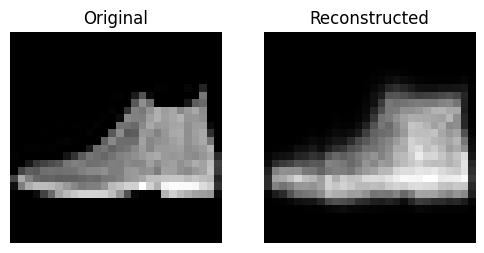

In [9]:
decoded_imgs = autoencoder.predict(x_test)

plt.figure(figsize=(6,3))

# Original Image
plt.subplot(1,2,1)
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title("Original")
plt.axis('off')

# Reconstructed Image
plt.subplot(1,2,2)
plt.imshow(decoded_imgs[0].reshape(28,28), cmap='gray')
plt.title("Reconstructed")
plt.axis('off')

plt.show()

Modify your autoencoder's loss function to use Binary Crossentropy (BCE) instead of Mean Squared Error (MSE), then compare the reconstruction quality visually for 3 test images.

In [10]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [11]:
autoencoder.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.2960 - val_loss: 0.2938
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.2907 - val_loss: 0.2919
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.2890 - val_loss: 0.2904
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2875 - val_loss: 0.2890
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2864 - val_loss: 0.2880


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


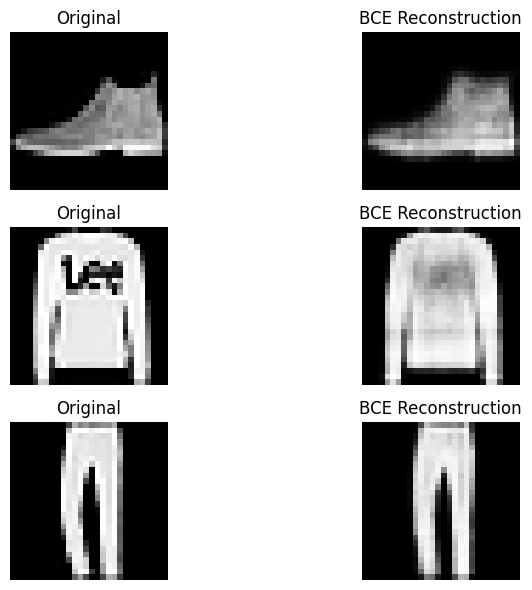

In [12]:
decoded_imgs = autoencoder.predict(x_test)

plt.figure(figsize=(9,6))

for i in range(3):

    # Original
    plt.subplot(3,2,2*i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(3,2,2*i+2)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("BCE Reconstruction")
    plt.axis('off')

plt.tight_layout()
plt.show()

Use your trained autoencoder to denoise images: add random noise to 10 Fashion MNIST test images, pass them through the autoencoder, and display the noisy and denoised outputs together.

In [13]:
noise_factor = 0.5

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_test_noisy = np.clip(x_test_noisy, 0., 1.)

In [14]:
denoised_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


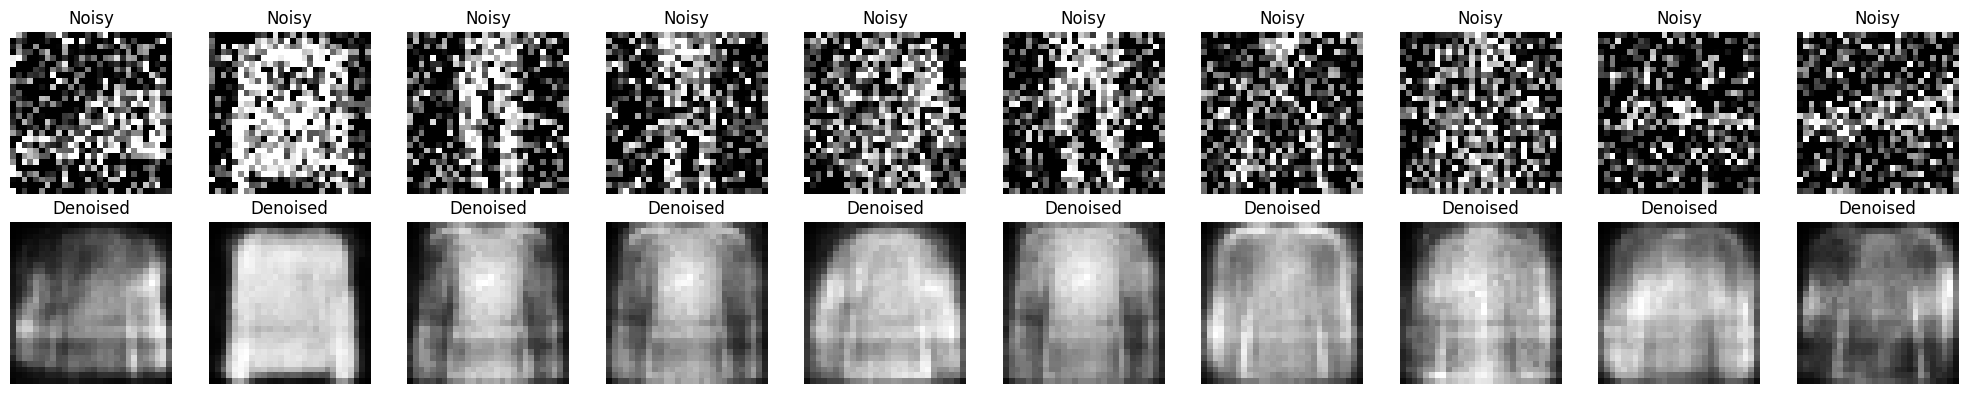

In [15]:
plt.figure(figsize=(20,4))

for i in range(10):

    # Noisy Image
    plt.subplot(2,10,i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised Image
    plt.subplot(2,10,i+11)
    plt.imshow(denoised_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()

Build a Variational Autoencoder (VAE) using Keras for the Fashion MNIST dataset. After training, sample 5 random points from the latent space and generate new images from these points.<

In [16]:
from tensorflow.keras.layers import Lambda
from tensorflow.keras import backend as K

In [17]:
latent_dim = 2

In [18]:
inputs = Input(shape=(784,))
h = Dense(256, activation='relu')(inputs)

z_mean = Dense(latent_dim)(h)
z_log_var = Dense(latent_dim)(h)

In [19]:
def sampling(args):
    z_mean, z_log_var = args

    epsilon = K.random_normal(
        shape=(K.shape(z_mean)[0], latent_dim)
    )

    return z_mean + K.exp(0.5 * z_log_var) * epsilon

In [21]:
z = Lambda(sampling)([z_mean, z_log_var])

In [22]:
decoder_h = Dense(256, activation='relu')
decoder_out = Dense(784, activation='sigmoid')

h_decoded = decoder_h(z)
outputs = decoder_out(h_decoded)

In [23]:
vae = Model(inputs, outputs)

In [28]:
from tensorflow.keras.layers import Layer

# 1. Define custom layer to handle VAE loss calculation
class VAELossLayer(Layer):
    def call(self, inputs_list):
        inputs, outputs, z_mean, z_log_var = inputs_list
        
        # Reconstruction loss
        reconstruction_loss = tf.keras.losses.binary_crossentropy(inputs, outputs)
        reconstruction_loss *= 784
        
        # KL Divergence loss
        kl_loss = -0.5 * tf.reduce_sum(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
            axis=-1
        )
        
        # Add VAE loss
        vae_loss = tf.reduce_mean(reconstruction_loss + kl_loss)
        self.add_loss(vae_loss)
        
        return outputs

# 2. Apply VAELossLayer to the functional model outputs
vae_outputs = VAELossLayer()([inputs, outputs, z_mean, z_log_var])

# 3. Instantiate and compile VAE Model
vae = Model(inputs, vae_outputs)
vae.compile(optimizer='adam')


In [29]:
vae.fit(
    x_train,
    epochs=5,
    batch_size=256,
    validation_data=(x_test, None)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 329.3484 - val_loss: 290.8695
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 285.5069 - val_loss: 283.6909
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 280.7478 - val_loss: 280.1883
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 277.9666 - val_loss: 277.8317
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 275.7127 - val_loss: 275.8404


In [30]:
latent_inputs = Input(shape=(latent_dim,))

x = decoder_h(latent_inputs)
outputs = decoder_out(x)

decoder = Model(latent_inputs, outputs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


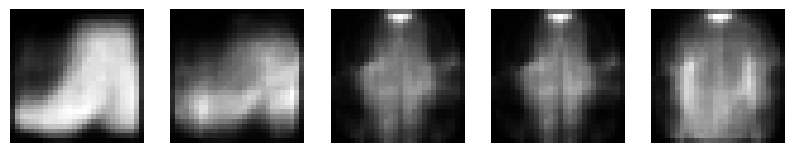

In [31]:
random_points = np.random.normal(size=(5, latent_dim))

generated = decoder.predict(random_points)

plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(generated[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

Use ChatGPT to explain in your own words what KL-divergence loss does in a VAE and why it is needed. Paste your prompt and ChatGPT's response as your answer.

prompt:-

Explain in simple words what KL-divergence loss does in a Variational Autoencoder (VAE) and why it is needed.



KL-divergence (Kullback-Leibler divergence) loss in a Variational Autoencoder measures how different the learned latent space distribution is from a standard normal distribution (mean = 0 and variance = 1).

A VAE has two objectives:

1. Reconstruction Loss: Ensures that the output image is similar to the input image.
2. KL-Divergence Loss: Regularizes the latent space so that it follows a normal distribution.

Without KL-divergence loss, the encoder may place data points randomly in the latent space, making it difficult to generate new meaningful images. KL-divergence forces similar images to be placed close together and creates a smooth, continuous latent space.

This regularization allows us to sample random points from the latent space and generate realistic new images, which is one of the main advantages of a VAE.
